<a href="https://colab.research.google.com/github/neji03/Discrete-Markov-Chain-Simulation/blob/main/NB_simulation_markov_TDiscret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Discrete Markov Chain Simulation Project

This notebook guides you step-by-step to simulate a 2-state Markov chain with Python.

**Objectives :**
- define the transition matrix;
- simulate a trajectory;
- count the passages in each state;
- calculate the theoretical distribution;
- calculate the observed distribution;
- compare the results with graphs.

## 1. Importer les bibliothèques

Commencez par importer les bibliothèques utiles.

Vous aurez besoin de :
- numpy pour les calculs numériques ;
- matplotlib.pyplot pour les graphiques.


In [27]:
import numpy as np
import matplotlib.pyplot as mp

## 2. Définir les paramètres

Choisissez :
- les probabilités de transition alpha et beta ;
- le nombre d'itérations N ;
- l'état initial $X_0$ ;
- la distribution initiale pi0.

Vous pouvez aussi fixer une graine aléatoire avec np.random.seed(...) pour obtenir les mêmes résultats à chaque exécution.


In [28]:
alpha =0.2
beta =0.5
N =1000
X0 =1
pi0 =np.array([0,1])


## 3. Construire la matrice de transition

La chaîne possède 2 états : 1 et 2.

Créez la matrice de transition avec numpy :

$$
P = \begin{pmatrix}
1-\alpha & \alpha \\
\beta & 1-\beta
\end{pmatrix}
$$




In [29]:
P=np.array([[1-alpha,alpha],[beta,1-beta]])
print(P)

[[0.8 0.2]
 [0.5 0.5]]


## 4. Initialiser le vecteur des états simulés

On veut stocker la trajectoire :
$$
X_0, X_1, X_2, \dots, X_N
$$

Créez un tableau etats de taille N+1, puis affectez l'état initial à la première position.


In [30]:
X = np.zeros(N+1)
X[0]=X0


## 5. Simuler la chaîne

À chaque étape :
1. on génère un nombre aléatoire uniforme u entre 0 et 1 ;
2. on regarde l'état courant ;
3. on décide du prochain état selon les probabilités de la ligne correspondante de P.



In [31]:
for i in range(N):
  u= np.random.rand()
  print(u)
  if X[i]==1:
    if u<1-alpha:
      X[i+1]=1
    else:
      X[i+1]=2
  else:
    if u<beta:
      X[i+1]=1
    else:
      X[i+1]=2


0.4079498614311933
0.24729038506445333
0.23007993284854822
0.3263887324806416
0.11510608461058669
0.3503236036360583
0.47969122875880355
0.6627552650599741
0.02176479009968857
0.33273669458202215
0.5528441754732073
0.3414333703571444
0.6791280433881892
0.38595293068715697
0.6022152952135628
0.9456391763813715
0.5396733332003673
0.7332563419257244
0.7787078615981836
0.6056638528650624
0.7723412860829794
0.9392335632313243
0.9688921045031117
0.3292457336315583
0.9898473621837351
0.8873502721838817
0.12953942916245698
0.982688884284967
0.05248569430952987
0.41286009960859504
0.3801942050449326
0.7863551152067398
0.4453998745052412
0.6461967059805171
0.3314097057491149
0.7789355103346554
0.6523944852811743
0.848284117202827
0.8085224338474774
0.08510646481877338
0.08024928139291809
0.23355046402151625
0.8967055864851498
0.11007261809119162
0.16191041185365707
0.8530331184476135
0.052553246578579516
0.31851633234110843
0.1993284050237517
0.3799986557726601
0.43215363538591434
0.220711161352

## 6. Compter les passages dans chaque état

Calculez combien de fois la chaîne est passée par l'état 1 et par l'état 2.

Vous pouvez utiliser np.sum(...)


In [32]:
x=np.sum(X==1)
y=np.sum(X==2)
print(x,y)

725 276


## 7. Calculer la distribution théorique

On rappelle la formule :
$$
\pi(n+1) = \pi(n) P
$$

Créez un tableau pit de taille (N+1, 2) et calculez la distribution théorique à chaque instant.


In [33]:
pit=np.zeros((N+1,2))
pit[0]=pi0
for i in range(N):
  pit[i+1]=np.dot(pit[i],P)
print(pit)


[[0.         1.        ]
 [0.5        0.5       ]
 [0.65       0.35      ]
 ...
 [0.71428571 0.28571429]
 [0.71428571 0.28571429]
 [0.71428571 0.28571429]]


## 8. Calculer la distribution observée

À l'instant n, la distribution observée est la fréquence des états observés jusqu'à cet instant.

Autrement dit :
- fréquence de l'état 1 = nombre de fois où l'état 1 apparaît / nombre total d'observations ;
- fréquence de l'état 2 = nombre de fois où l'état 2 apparaît / nombre total d'observations.


In [34]:
distr=np.zeros(N+1)
feq1=0
freq2=0
for i in range(N+1):
  if X[i]==1:
    feq1=feq1+1
  else:
    freq2=freq2+1
  distr[i]=feq1/(i+1)
  distr[i]=freq2/(i+1)
print(distr)



[0.         0.         0.         ... 0.27527528 0.275      0.27572428]


## 9. Afficher les résultats finaux

Affichez :
- la matrice de transition ;
- le nombre de passages dans chaque état ;
- la distribution théorique finale ;
- la distribution observée finale.


In [35]:
print(P)
print(x,y)
print(pit)
print(distr)


[[0.8 0.2]
 [0.5 0.5]]
725 276
[[0.         1.        ]
 [0.5        0.5       ]
 [0.65       0.35      ]
 ...
 [0.71428571 0.28571429]
 [0.71428571 0.28571429]
 [0.71428571 0.28571429]]
[0.         0.         0.         ... 0.27527528 0.275      0.27572428]


## 10. Tracer la trajectoire simulée

Tracez une partie raisonnable de la trajectoire, par exemple les 50 ou 100 premiers instants.


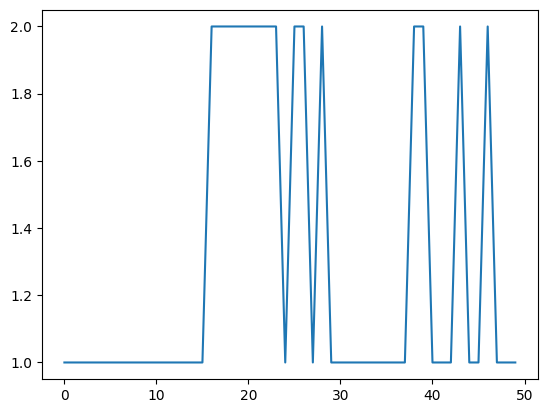

In [39]:
tr=np.zeros(50)
for i in range(50):
  if X[i]==1:
    tr[i]=1
  else:
    tr[i]=2
mp.plot(tr)


## 11. Comparer les probabilités théoriques et observées

Sur un même graphique, tracez :
- les probabilités théoriques des états 1 et 2 ;
- les probabilités observées des états 1 et 2.


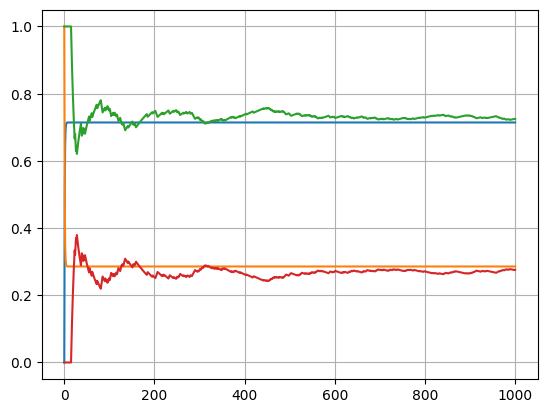

In [38]:
mp.figure()
mp.plot(pit[:, 0], label='Théo 1')
mp.plot(pit[:, 1], label='Thé 2')

mp.plot(1 - distr, label='Observé 1')
mp.plot(distr, label='Observé 2')

mp.grid(True)
mp.show()